In [146]:
import mofr

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
from support_functions import calculate_MACD, calculate_regression_model_price, calc_vol_intensity_index
tol=(1e-1)/2

import seaborn as sns


In [148]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [149]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [150]:
import warnings
warnings.filterwarnings('ignore')

In [151]:
burnout_period=30
stop_profit=0.3
makeagg_ratio=0.6
trail_stop=0

take_profit=1
stop_loss=-1

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [152]:
##########################
param_dict = {}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop


param_dict['br_fee'] = br_fee
##########################


strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.param_dict=param_dict

# Data preparation

In [153]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jan_feb.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jan_feb.csv',
                    parse_dates=['datetime']).reset_index()

In [154]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [155]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [156]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [157]:
data_lag['date']=data_lag['datetime'].apply(lambda x: x.date())

## Predictor calculation

In [158]:
data_lag['timestamp']=data_lag['datetime']
data_lead['timestamp']=data_lead['datetime']

data_lag=calculate_MACD(data_lag, 6,14)
data_lag=calculate_MACD(data_lag, 12,26)
data_lag=calculate_MACD(data_lag, 18,38)

data_lead=calculate_regression_model_price(data_lead, data_lag, 10, 10, 3)

        
data_lag['tag']='lag'
data_lead['tag']='lead'

data_lag= pd.concat([data_lag, data_lead[['datetime', 'timestamp', 'tag', 'trd_price', 'lag_price_predicted', 'lag_price_predicted_datetime', 'lag_price_tick', 'coef1', 'coef2', 'lead_price_tick']].reset_index(drop=True)]).reset_index(
    drop=True).sort_values('datetime').reset_index()

del data_lag['level_0'], data_lag['index']

# Convert the timestamp to date and set it as a separate column if not already done
data_lag['date'] = data_lag['datetime'].dt.date


data_lag=calc_vol_intensity_index(data_lag, 3, 'lead')
data_lag=calc_vol_intensity_index(data_lag, 5, 'lead')
data_lag=calc_vol_intensity_index(data_lag, 10, 'lead')
data_lag=calc_vol_intensity_index(data_lag, 3, 'lag')
data_lag=calc_vol_intensity_index(data_lag, 5, 'lag')
data_lag=calc_vol_intensity_index(data_lag, 10, 'lag')



# Forward fill within each day
data_lag['bid_price'] = data_lag.groupby('date')['bid_price'].ffill()
data_lag['ask_price'] = data_lag.groupby('date')['ask_price'].ffill()
data_lag['mid_price'] = data_lag.groupby('date')['mid_price'].ffill()
data_lag['MACD_6_14'] = data_lag.groupby('date')['MACD_6_14'].ffill()
data_lag['MACD_12_26'] = data_lag.groupby('date')['MACD_12_26'].ffill()
data_lag['MACD_18_38'] = data_lag.groupby('date')['MACD_18_38'].ffill()


data_lag=data_lag.dropna(subset=['bid_price', 'ask_price', 'mid_price'])

In [159]:
data_lag.head()

,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,date,timestamp,...,lag_price_tick,coef1,coef2,lead_price_tick,VII_lead_3,VII_lead_5,VII_lead_10,VII_lag_3,VII_lag_5,VII_lag_10
1,2024-01-02 09:00:26.000000000,NaN,NaN,83.25,86.37,84.81,1.0,269.0,2024-01-02,2024-01-02 09:00:26.000000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-02 09:00:30.000000000,NaN,NaN,83.25,86.25,84.75,1.0,4.0,2024-01-02,2024-01-02 09:00:30.000000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-02 09:00:40.962116718,92.00,NaN,83.25,86.25,84.75,NaN,NaN,2024-01-02,2024-01-02 09:00:40.962116718,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-02 09:00:41.104269743,91.97,NaN,83.25,86.25,84.75,NaN,NaN,2024-01-02,2024-01-02 09:00:41.104269743,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-01-02 09:00:41.159442425,92.00,NaN,83.25,86.25,84.75,NaN,NaN,2024-01-02,2024-01-02 09:00:41.159442425,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


## Target Calculation

In [160]:
def calculate_close_slot_long(open_price, open_time, row):
    
        if (row['ask_price']-row['bid_price']>param_dict['ba_max']) or row['tag']!='lag':
            return (0,0)
    
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        strategy_class.tag=row['tag']
        
        #strategy_class.MACD = row['MACD']
        #strategy_class.lag_price_predicted_datetime = row['lag_price_predicted_datetime']
        #strategy_class.lag_price_tick = row['lag_price_tick']
        #strategy_class.lead_price_tick = row['lead_price_tick']
        
        #strategy_class.coef1 = row['coef1']
        #strategy_class.coef2 = row['coef2']

        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=1
        
        return strategy_class.calculate_close_slot()
    
def calculate_close_slot_short(open_price, open_time, row):

        if row['ask_price']-row['bid_price']>param_dict['ba_max'] or row['tag']!='lag':
            return (0,0)
        
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        strategy_class.tag=row['tag']
        
        
#         strategy_class.MACD = row['MACD']
#         strategy_class.lag_price_predicted_datetime = row['lag_price_predicted_datetime']
#         strategy_class.lag_price_tick = row['lag_price_tick']
#         strategy_class.lead_price_tick = row['lead_price_tick']
        
#         strategy_class.coef1 = row['coef1']
#         strategy_class.coef2 = row['coef2']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=-1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=-1
        
        return strategy_class.calculate_close_slot()

    
def calculate_profit_long(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['ask_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_long(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return price-open_price-2*param_dict['br_fee']
    
    return 0

def calculate_profit_short(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['bid_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_short(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return open_price-price-2*param_dict['br_fee']
    
    return 0

In [161]:
df_filtered=data_lag[data_lag['tag']=='lead']

In [162]:
for date in sorted(list(set(df_filtered.date))):
    print(date)
    a=data_lag[data_lag['date']==date]
    df_filtered.loc[df_filtered['date']==date, 'profit_long']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_long(row, a), axis=1)
    df_filtered.loc[df_filtered['date']==date, 'profit_short']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_short(row, a), axis=1)

2024-01-02
2024-01-03
2024-01-04
2024-01-05
2024-01-08
2024-01-09
2024-01-10
2024-01-11
2024-01-12
2024-01-15
2024-01-16
2024-01-17
2024-01-18
2024-01-19
2024-01-22
2024-01-23
2024-01-24
2024-01-25
2024-01-26
2024-01-29
2024-01-30
2024-01-31
2024-02-01
2024-02-02
2024-02-05
2024-02-06
2024-02-07
2024-02-08
2024-02-09
2024-02-12
2024-02-13
2024-02-14
2024-02-15
2024-02-16
2024-02-19
2024-02-20
2024-02-21
2024-02-22
2024-02-23
2024-02-26
2024-02-27
2024-02-28
2024-02-29


In [163]:
#df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]

In [164]:
df_filtered.to_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jan_feb_enriched.csv')

# Model Calculation

In [165]:
seed=2

In [166]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score

In [167]:
df_filtered['VII_3_ratio']=(df_filtered['VII_lead_3']/df_filtered['VII_lag_3'].replace(0, 0.00001)).apply(float)
df_filtered['VII_5_ratio']=(df_filtered['VII_lead_5']/df_filtered['VII_lag_5'].replace(0, 0.00001)).apply(float)
df_filtered['VII_10_ratio']=(df_filtered['VII_lead_10']/df_filtered['VII_lag_10'].replace(0, 0.00001)).apply(float)

In [168]:
df_filtered['ba_spread']=df_filtered['ask_price']-df_filtered['bid_price']

In [169]:
feature_cols=[
    'MACD_6_14',
    'MACD_12_26', 
    'MACD_18_38', 
    'VII_lead_3', 
    'VII_lead_5', 
    'VII_lead_10',
    'VII_lag_3', 
    'VII_lag_5', 
    'VII_lag_10',
    
    'VII_3_ratio',
    'VII_5_ratio',
    'VII_10_ratio',
    
    'price_diff',
    'ba_spread']

## Long model 

In [170]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['ask_price']

In [171]:
df_modelling=df_filtered.replace([np.inf, -np.inf], None).dropna(subset=feature_cols+['profit_long', 'profit_short'])

### Regression

In [172]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce')
y_train = df_modelling['profit_long'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            profit_long   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     53.76
Date:                Mon, 07 Oct 2024   Prob (F-statistic):          4.28e-150
Time:                        14:13:29   Log-Likelihood:                -31997.
No. Observations:               40031   AIC:                         6.402e+04
Df Residuals:                   40016   BIC:                         6.415e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0143      0.006     -2.426   

### XGBoost

In [173]:
df_modelling['y']=(df_modelling['profit_long']>0).apply(int)
df_modelling['y'].value_counts()

y
0    28172
1    11859
Name: count, dtype: int64

In [174]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce'), df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce'))[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols].apply(pd.to_numeric, errors='coerce'))[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols].apply(pd.to_numeric, errors='coerce'))[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols].apply(pd.to_numeric, errors='coerce'))

xgb_model.save_model('xgboost_model_dem2_dem1_jan_feb_long.json')

In [175]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 2.0339694400472217
The gini on the df set is: 0.37466225157499533
The accuracy on the df set is: 0.7161176431402592


The Lift on the test set is: 2.024146764679963
The gini on the test set is: 0.3515933878207609
The accuracy on the test set is: 0.7074340527577938




In [176]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD_6_14,0.065093
1,MACD_12_26,0.097980
2,MACD_18_38,0.114675
3,VII_lead_3,0.019836
4,VII_lead_5,0.023126
5,VII_lead_10,0.031163
6,VII_lag_3,0.047362
7,VII_lag_5,0.047439
8,VII_lag_10,0.070973
9,VII_3_ratio,-0.010965


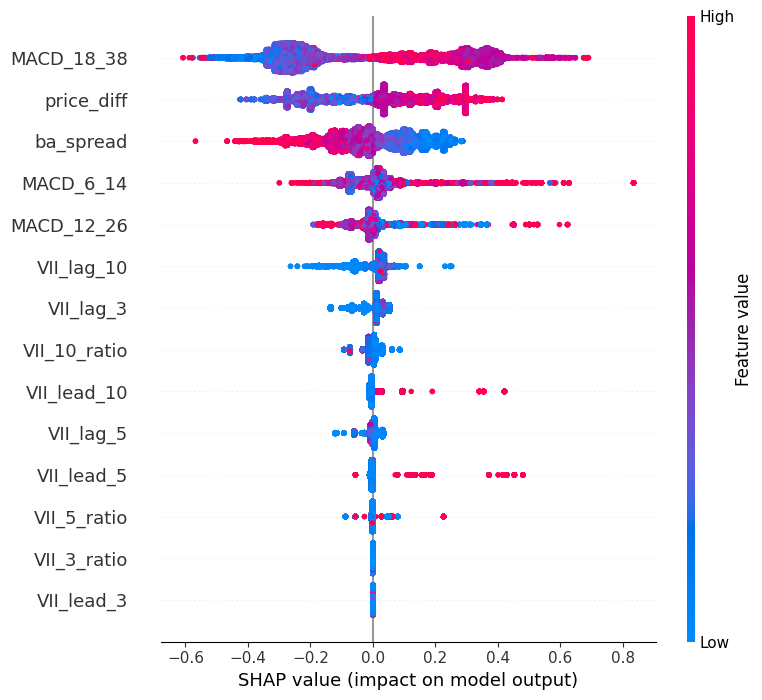

In [177]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce'))
shap.summary_plot(shap_values, df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce'))
plt.show()

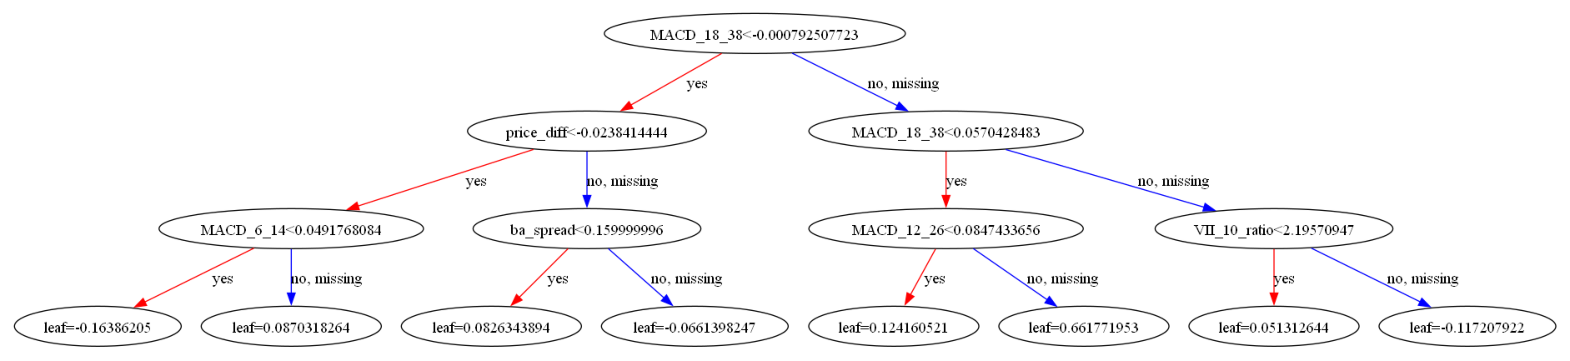

In [178]:
fig, ax = plt.subplots(figsize=(20, 20))
xgb.plot_tree(xgb_model, num_trees=0, rankdir='UT', ax=ax)
plt.show()

#### **Precision curve**

In [179]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.5, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [180]:
prec_recall_df[-50:]

,thold,precision,recall,count
250,0.450,0.701493,0.124545,536
251,0.451,0.702804,0.124545,535
252,0.452,0.704120,0.124545,534
253,0.453,0.752412,0.077509,311
254,0.454,0.750809,0.076847,309
255,0.455,0.749186,0.076184,307
256,0.456,0.748344,0.074859,302
257,0.457,0.747508,0.074528,301
258,0.458,0.750842,0.073866,297
259,0.459,0.750853,0.072872,293


## Short model 

In [181]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['bid_price']

In [182]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce')
y_train = df_modelling['profit_short'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           profit_short   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     104.3
Date:                Mon, 07 Oct 2024   Prob (F-statistic):          5.63e-298
Time:                        14:13:34   Log-Likelihood:                -10776.
No. Observations:               40031   AIC:                         2.158e+04
Df Residuals:                   40016   BIC:                         2.171e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0568      0.003    -16.411   

### XGBoost

In [183]:
df_modelling['y']=(df_modelling['profit_short']>0).apply(int)
df_modelling['y'].value_counts()

y
0    26832
1    13199
Name: count, dtype: int64

In [184]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce'), df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce'))[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols].apply(pd.to_numeric, errors='coerce'))[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols].apply(pd.to_numeric, errors='coerce'))[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols].apply(pd.to_numeric, errors='coerce'))

xgb_model.save_model('xgboost_model_dem2_dem1_jan_feb_short.json')

In [185]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.8912986417579805
The gini on the df set is: 0.33579005531033523
The accuracy on the df set is: 0.6869067048596076


The Lift on the test set is: 1.8424769874476987
The gini on the test set is: 0.3197645404981335
The accuracy on the test set is: 0.6802557953637091




In [186]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD_6_14,-0.061888
1,MACD_12_26,-0.084525
2,MACD_18_38,-0.100312
3,VII_lead_3,0.007951
4,VII_lead_5,0.006933
5,VII_lead_10,0.007435
6,VII_lag_3,-0.009165
7,VII_lag_5,-0.007563
8,VII_lag_10,-0.014490
9,VII_3_ratio,0.005397


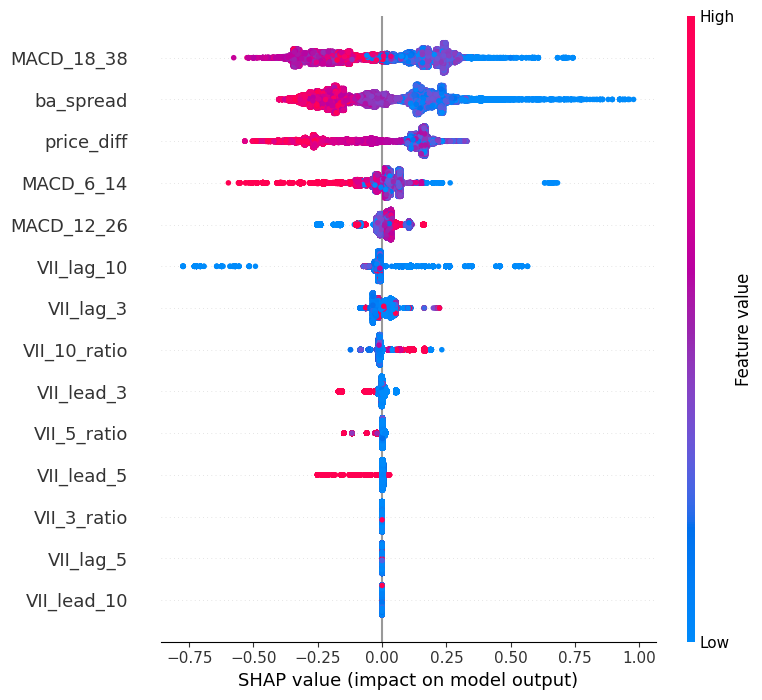

In [187]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce'))
shap.summary_plot(shap_values, df_modelling[feature_cols].apply(pd.to_numeric, errors='coerce'))
plt.show()

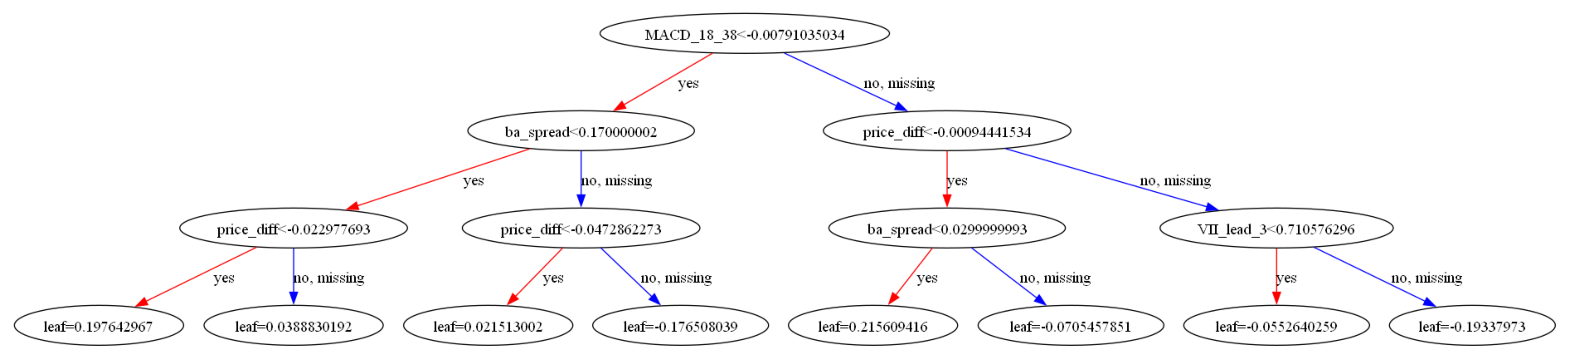

In [188]:
fig, ax = plt.subplots(figsize=(20, 20))
xgb.plot_tree(xgb_model, num_trees=0, rankdir='UT', ax=ax)
plt.show()

#### **Precision curve**

In [189]:
preds_p = xgb_model.predict_proba(X_test[feature_cols].apply(pd.to_numeric, errors='coerce'))[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.52, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [190]:
prec_recall_df[-50:]

,thold,precision,recall,count
270,0.470,0.673333,0.120741,600
271,0.471,0.673913,0.120442,598
272,0.472,0.674216,0.115660,574
273,0.473,0.675439,0.115063,570
274,0.474,0.675439,0.115063,570
275,0.475,0.673145,0.113867,566
276,0.476,0.673145,0.113867,566
277,0.477,0.674377,0.113270,562
278,0.478,0.718310,0.091452,426
279,0.479,0.722749,0.091154,422
